# ***Mount Google Drive & Load CSV Files***

In [1]:
!pip install --upgrade transformers

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import numpy as np
import pandas as pd

# Set your path correctly
train_path = '/content/drive/MyDrive/Train_preprocessed.csv'
test_path = '/content/drive/MyDrive/Test_preprocessed.csv'
valid_path = '/content/drive/MyDrive/Valid_preprocessed.csv'

train_df = pd.read_csv(train_path, )
test_df = pd.read_csv(test_path, )
val_df = pd.read_csv(valid_path, )


In [ ]:
train_df = train_df[["clean_text", "label"]]
val_df = val_df[["clean_text", "label"]]
test_df = test_df[["clean_text", "label"]]

In [ ]:
train_df.shape

(30000, 2)

In [ ]:
train_df.head()

,clean_text,label
0,goal u global anaconda strategy limit living s...,1
1,fox news went completely predictable opening t...,1
2,u entirely responsible demise inf treaty actio...,1
3,new leaked clinton email came device anthony w...,1
4,authority thailand southeastern chonburi provi...,0


In [ ]:
test_df.head()

,clean_text,label
0,nordstrom cancelled ivanka trump line liberal ...,1
1,donald trump president jeff session attorney g...,1
2,day candidate squared fiery debate came columb...,0
3,nato deployed force eastern europe order prepa...,1
4,russian president vladimir putin said wednesda...,0


# ***Tokenize Using mBERT***

In [ ]:
from transformers import BertTokenizer
from datasets import Dataset

In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

In [ ]:
train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
test_ds = Dataset.from_pandas(test_df)


In [ ]:
print(train_ds[0])          # single example
print(train_ds[0]["clean_text"])
print(type(train_ds[0]["clean_text"]))

print(train_ds[:5]["clean_text"])  # first 5 values


{'clean_text': 'goal u global anaconda strategy limit living space geopolitical opponent provoke proxy war manipulate historical difference among regional player south caucasus', 'label': 1}
goal u global anaconda strategy limit living space geopolitical opponent provoke proxy war manipulate historical difference among regional player south caucasus
<class 'str'>
['goal u global anaconda strategy limit living space geopolitical opponent provoke proxy war manipulate historical difference among regional player south caucasus', 'fox news went completely predictable opening tonight republican debate megyn kelly addressed elephant room asking ted cruz comment donald trump absence sleazy pandering people iowa cruz slung mud trump kind swagger confidence boxer talking opponent press conference absencecruz got nice chuckle crowd comment witty delivered screeching whiny little voice annoying pursed lip egotistical little moment would probably smacked going make america great something equally c

In [ ]:
train_ds = train_ds.filter(lambda x: isinstance(x["clean_text"], str))
val_ds   = val_ds.filter(lambda x: isinstance(x["clean_text"], str))
test_ds  = test_ds.filter(lambda x: isinstance(x["clean_text"], str))


Filter:   0%|          | 0/30000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/6000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/6000 [00:00<?, ? examples/s]

In [ ]:
def tokenize_fn(batch):
    return tokenizer(
        batch["clean_text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [ ]:
train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds   = val_ds.map(tokenize_fn, batched=True)
test_ds  = test_ds.map(tokenize_fn, batched=True)


Map:   0%|          | 0/29949 [00:00<?, ? examples/s]

Map:   0%|          | 0/5988 [00:00<?, ? examples/s]

Map:   0%|          | 0/5983 [00:00<?, ? examples/s]

In [ ]:
train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore", message="Unable to avoid copy*")
os.environ["WANDB_DISABLED"] = "true"

# ***Laod and Train Model(mBERT)***

In [ ]:
from transformers import BertForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [ ]:
model = BertForSequenceClassification.from_pretrained("bert-base-multilingual-cased", num_labels=3)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='macro')
    acc = accuracy_score(labels, predictions)
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    do_train=True,
    do_eval=True,
    eval_strategy="epoch",           # evaluate every epoch ✅
    save_strategy="epoch",                 # save every epoch ✅
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,          # works now
    metric_for_best_model="f1"
)


In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


/tmp/ipython-input-2291226403.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.195300,0.140630,0.951904,0.949619,0.950776,0.950186
2,0.118400,0.151189,0.959252,0.961433,0.954140,0.957420
3,0.061600,0.189894,0.962759,0.960673,0.962263,0.961446
4,0.025900,0.203122,0.965765,0.963256,0.966100,0.964607
5,0.011400,0.217278,0.967769,0.966718,0.966411,0.966563


TrainOutput(global_step=9360, training_loss=0.09328152114509518, metrics={'train_runtime': 3803.8922, 'train_samples_per_second': 39.366, 'train_steps_per_second': 2.461, 'total_flos': 9849979684419840.0, 'train_loss': 0.09328152114509518, 'epoch': 5.0})

# *****Evaluation (Accuracy,F1,Confusion Matric)*****

In [ ]:
import numpy as np
from scipy.special import softmax
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)
import matplotlib.pyplot as plt

In [ ]:
results = trainer.evaluate(eval_dataset=test_ds)
print("📊 Final Test Set Evaluation Results:")
print(results)


📊 Final Test Set Evaluation Results:
{'eval_loss': 0.2599503993988037, 'eval_accuracy': 0.9640648504094935, 'eval_precision': 0.9632442693104457, 'eval_recall': 0.9623559585376043, 'eval_f1': 0.9627934218016557, 'eval_runtime': 40.7324, 'eval_samples_per_second': 146.886, 'eval_steps_per_second': 9.182, 'epoch': 5.0}


In [ ]:
# 1) Choose which split to evaluate on
#    use val_ds or tokenized_datasets["test"] etc.
eval_dataset = val_ds   # or tokenized_datasets["test"]

# 2) Get raw predictions from Trainer
pred_output = trainer.predict(eval_dataset)

logits = pred_output.predictions          # shape: [N, num_labels]
y_true = pred_output.label_ids            # true labels

# 3) Convert logits -> probabilities and hard predictions
probs = softmax(logits, axis=1)           # softmax over classes
y_pred = np.argmax(probs, axis=1)

print("Predictions shape:", logits.shape)
print("Labels shape     :", y_true.shape)

Predictions shape: (5988, 3)
Labels shape     : (5988,)


In [ ]:
# 4) Classification report
target_names = [f"Class {i}" for i in np.unique(y_true)]
print("\n=== Classification report ===")
print(classification_report(y_true, y_pred, target_names=target_names))


=== Classification report ===
              precision    recall  f1-score   support

     Class 0       0.96      0.96      0.96      2428
     Class 1       0.97      0.97      0.97      3560

    accuracy                           0.97      5988
   macro avg       0.97      0.97      0.97      5988
weighted avg       0.97      0.97      0.97      5988



<Figure size 400x400 with 0 Axes>

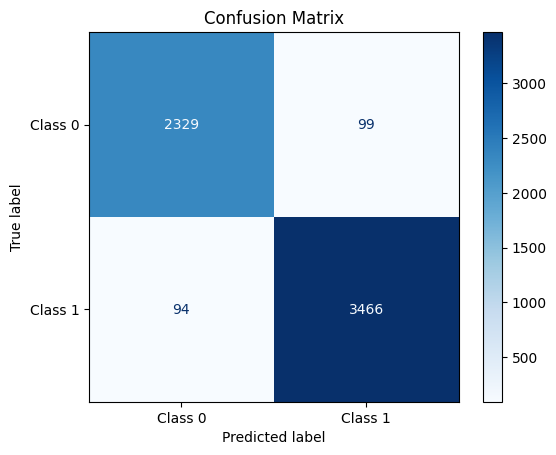

In [ ]:
# 5) Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

plt.figure(figsize=(4, 4))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import os

save_dir = "/content/drive/MyDrive/mbert_propaganda_trained"

# Trainer knows about model; this saves model + config + tokenizer
trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)

print("Model + tokenizer saved to:", save_dir)

Model + tokenizer saved to: /content/drive/MyDrive/mbert_propaganda_trained


In [ ]:
import torch

state_pkl_path = "/content/drive/MyDrive/mbert_propaganda_state_dict.pkl"
torch.save(model.state_dict(), state_pkl_path)

print("State dict saved to:", state_pkl_path)

State dict saved to: /content/drive/MyDrive/mbert_propaganda_state_dict.pkl


# ***NLP+Backlinks (Outlet Level Predictions)***

In [ ]:
backlink_path = "/content/drive/MyDrive/extracted_results_separate_steps.xlsx"

backlink_df = pd.read_excel(backlink_path)

print(backlink_df.shape)
print(backlink_df.columns.tolist())
backlink_df.head()


(28, 11)
['row_index', 'source_url', 'source_title', 'source_text', 'source_date', 'source_language', 'target_url', 'target_title', 'target_text', 'target_date', 'target_language']


,row_index,source_url,source_title,source_text,source_date,source_language,target_url,target_title,target_text,target_date,target_language
0,0,https://domains.bugcrew.net/domains/rest,NaN,NaN,NaN,NaN,https://restmedia.st/,REST - Home,"Vagharshapat (Etchmiadzin), Armenia’s fourth-l...",NaN,en
1,1,https://domains.bugcrew.net/domains/rest/9,NaN,NaN,NaN,NaN,https://restmedia.st/,REST - Home,"Vagharshapat (Etchmiadzin), Armenia’s fourth-l...",NaN,en
2,2,https://dstormer6em3i4km.onion.pw/sources,NaN,NaN,NaN,NaN,https://restmedia.st/feed/,REST,"<p>Vagharshapat (Etchmiadzin), Armenia’s fourt...",2025-11-29T18:35:50+00:00,en
3,3,https://dstormer6em3i4km.onion.pw/sources,NaN,NaN,NaN,NaN,https://restmedia.st/,REST - Home,"Vagharshapat (Etchmiadzin), Armenia’s fourth-l...",NaN,en
4,4,https://elstormer6vrre53.onion.pw/sources,NaN,NaN,NaN,NaN,https://restmedia.st/feed/,REST,"<p>Vagharshapat (Etchmiadzin), Armenia’s fourt...",2025-11-29T18:35:50+00:00,en


In [ ]:
SOURCE_TEXT_COL = "source_text"
TARGET_TEXT_COL = "target_text"
TARGET_URL_COL  = "target_url"

In [ ]:
import torch.nn.functional as F

In [ ]:
MAX_LENGTH = 256  # same as training

def predict_texts(text_list, batch_size=16):
    all_probs = []
    all_preds = []

    for i in range(0, len(text_list), batch_size):
        batch_texts = text_list[i:i+batch_size]

        # ensure everything is string
        batch_texts = ["" if x is None else str(x) for x in batch_texts]

        encodings = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**encodings)
            logits = outputs.logits                    # [B, num_labels]

            # 🔹 Use PyTorch softmax, not SciPy
            probs = F.softmax(logits, dim=-1).cpu().numpy()
            preds = np.argmax(probs, axis=1)

        all_probs.extend(probs)
        all_preds.extend(preds)

    return np.array(all_probs), np.array(all_preds)


In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

source_texts = backlink_df[SOURCE_TEXT_COL].fillna("").tolist()
target_texts = backlink_df[TARGET_TEXT_COL].fillna("").tolist()

source_probs, source_preds = predict_texts(source_texts, batch_size=16)
backlink_df["source_pred"]      = source_preds
backlink_df["source_prob_prop"] = source_probs[:, 1]

target_probs, target_preds = predict_texts(target_texts, batch_size=16)
backlink_df["target_pred"]      = target_preds
backlink_df["target_prob_prop"] = target_probs[:, 1]

In [ ]:
from urllib.parse import urlparse

# make sure this matches your column name
TARGET_URL_COL = "target_url"

def extract_domain(url):
    try:
        netloc = urlparse(str(url)).netloc
        # strip leading "www."
        if netloc.startswith("www."):
            netloc = netloc[4:]
        return netloc
    except Exception:
        return ""

# create outlet/domain column
backlink_df["outlet_domain"] = backlink_df[TARGET_URL_COL].apply(extract_domain)

# quick sanity check
print("Unique outlets:", backlink_df["outlet_domain"].nunique())
print(backlink_df["outlet_domain"].value_counts().head())

backlink_df.head(28)


Unique outlets: 1
outlet_domain
restmedia.st    28
Name: count, dtype: int64


,row_index,source_url,source_title,source_text,source_date,source_language,target_url,target_title,target_text,target_date,target_language,source_pred,source_prob_prop,target_pred,target_prob_prop,outlet_domain
0,0,https://domains.bugcrew.net/domains/rest,NaN,NaN,NaN,NaN,https://restmedia.st/,REST - Home,"Vagharshapat (Etchmiadzin), Armenia’s fourth-l...",NaN,en,1,0.999804,0,0.004119,restmedia.st
1,1,https://domains.bugcrew.net/domains/rest/9,NaN,NaN,NaN,NaN,https://restmedia.st/,REST - Home,"Vagharshapat (Etchmiadzin), Armenia’s fourth-l...",NaN,en,1,0.999804,0,0.004119,restmedia.st
2,2,https://dstormer6em3i4km.onion.pw/sources,NaN,NaN,NaN,NaN,https://restmedia.st/feed/,REST,"<p>Vagharshapat (Etchmiadzin), Armenia’s fourt...",2025-11-29T18:35:50+00:00,en,1,0.999804,0,0.001090,restmedia.st
3,3,https://dstormer6em3i4km.onion.pw/sources,NaN,NaN,NaN,NaN,https://restmedia.st/,REST - Home,"Vagharshapat (Etchmiadzin), Armenia’s fourth-l...",NaN,en,1,0.999804,0,0.004119,restmedia.st
4,4,https://elstormer6vrre53.onion.pw/sources,NaN,NaN,NaN,NaN,https://restmedia.st/feed/,REST,"<p>Vagharshapat (Etchmiadzin), Armenia’s fourt...",2025-11-29T18:35:50+00:00,en,1,0.999804,0,0.001090,restmedia.st
5,5,https://friendica.eskimo.com/community/global?...,Community | Friendica Social Network,Protestation (Deutsch) 3 months ago from Prote...,2025-08-14T11:01:07,en,https://restmedia.st/armenian-pows-in-azerbaij...,"Armenian POWs in Azerbaijan: Sham Trials, Repr...",By Rest Rest Prisoners of War Turned Political...,2025-08-11T00:00:00,en,1,0.999902,0,0.000176,restmedia.st
6,6,https://alamoana.net/info/en/?search=Right_of_...,Right Of Return - Encyclopedia Information,The right of return is a principle in internat...,NaN,en,https://restmedia.st/nagorno-karabakh-displace...,Nagorno-Karabakh Displaced: Right of Return Sa...,By Rest Rest In the aftermath of Azerbaijan’s ...,2025-07-22T00:00:00,en,0,0.011642,1,0.979815,restmedia.st
7,7,https://dfrlab.org/2025/09/23/sanctioned-russi...,Sanctioned Russian actor linked to new media o...,"September 23, 2025 by Jakub Kubś and Eto Buzia...",2025-09-23T07:00:00+00:00,en,https://restmedia.st/category/countries/moldova/,Moldova Archives - REST,A Surprise Newcomer Faces Losing Its Seats Mol...,NaN,en,0,0.287679,0,0.000231,restmedia.st
8,8,https://dfrlab.org/2025/09/23/sanctioned-russi...,Sanctioned Russian actor linked to new media o...,"September 23, 2025 by Jakub Kubś and Eto Buzia...",2025-09-23T07:00:00+00:00,en,https://restmedia.st/eu-grants-as-political-le...,EU Grants as Political Leverage and Blackmail ...,"By Rest Rest In Moldova, the ruling pro-Europe...",2025-09-01T00:00:00,en,0,0.287679,0,0.000422,restmedia.st
9,9,https://dfrlab.org/2025/09/23/sanctioned-russi...,Sanctioned Russian actor linked to new media o...,"September 23, 2025 by Jakub Kubś and Eto Buzia...",2025-09-23T07:00:00+00:00,en,https://restmedia.st/moldovas-supreme-security...,Moldova’s Supreme Security Council Reform: Unc...,By Rest Rest A “Security” Reform to Expand Pre...,2025-08-04T00:00:00,en,0,0.287679,0,0.000090,restmedia.st


In [ ]:
import numpy as np
import pandas as pd

def ratio_prop(series):
    # fraction of rows predicted as propaganda (1)
    if len(series) == 0:
        return np.nan
    return (series == 1).mean()

outlet_stats = (
    backlink_df
    .groupby("outlet_domain")
    .agg(
        n_links              = ("outlet_domain", "size"),   # how many backlinks in our sample
        target_prop_ratio    = ("target_pred", ratio_prop), # share of target pages labeled propaganda
        incoming_prop_ratio  = ("source_pred", ratio_prop), # share of source pages labeled propaganda
        avg_source_prob_prop = ("source_prob_prop", "mean"),
        avg_target_prob_prop = ("target_prob_prop", "mean"),
    )
    .reset_index()
)

print(outlet_stats.shape)
outlet_stats.head()


(1, 6)


,outlet_domain,n_links,target_prop_ratio,incoming_prop_ratio,avg_source_prob_prop,avg_target_prob_prop
0,restmedia.st,28,0.357143,0.642857,0.714632,0.354895


In [ ]:
# you can tune these
CONTENT_THRESH = 0.6   # 60% of its own pages predicted propaganda
NETWORK_THRESH = 0.6   # 60% of sources linking to it predicted propaganda

def classify_outlet(row):
    content_high = row["target_prop_ratio"]   >= CONTENT_THRESH
    network_high = row["incoming_prop_ratio"] >= NETWORK_THRESH

    if content_high and network_high:
        return "propaganda_outlet"
    elif content_high and not network_high:
        return "content_leaning_propaganda"
    elif network_high and not content_high:
        return "network_leaning_propaganda"
    else:
        return "mainly_legitimate"

outlet_stats["outlet_label"] = outlet_stats.apply(classify_outlet, axis=1)

# see top few outlets sorted by network propaganda ratio
outlet_stats.sort_values("incoming_prop_ratio", ascending=False).head(10)


,outlet_domain,n_links,target_prop_ratio,incoming_prop_ratio,avg_source_prob_prop,avg_target_prob_prop,outlet_label
0,restmedia.st,28,0.357143,0.642857,0.714632,0.354895,network_leaning_propaganda


In [ ]:
outlet_csv_path = "/content/drive/MyDrive/outlet_level_credibility.csv"
outlet_pkl_path = "/content/drive/MyDrive/outlet_level_credibility.pkl"

outlet_stats.to_csv(outlet_csv_path, index=False)
outlet_stats.to_pickle(outlet_pkl_path)

print("Outlet-level CSV saved to:", outlet_csv_path)
print("Outlet-level PKL saved to:", outlet_pkl_path)


Outlet-level CSV saved to: /content/drive/MyDrive/outlet_level_credibility.csv
Outlet-level PKL saved to: /content/drive/MyDrive/outlet_level_credibility.pkl


# ***Output Level Prediction***

In [5]:
!pip install -q gradio openpyxl

In [6]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd

from transformers import BertTokenizer, BertForSequenceClassification # Changed to import specific classes
from urllib.parse import urlparse

import gradio as gr

# 1) Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 2) Load fine-tuned model + tokenizer
MODEL_PATH = "/content/drive/MyDrive/mbert_propaganda_trained"  # <-- change this path

# Explicitly load BertTokenizer and BertForSequenceClassification
tokenizer = BertTokenizer.from_pretrained(MODEL_PATH)
model = BertForSequenceClassification.from_pretrained(MODEL_PATH).to(device)
model.eval()

print("Loaded model from:", MODEL_PATH)
print("Num labels:", model.config.num_labels)


Using device: cuda
Loaded model from: /content/drive/MyDrive/mbert_propaganda_trained
Num labels: 3


In [7]:
MAX_LENGTH = 256  # same as training

def predict_texts(text_list, batch_size=16):
    all_probs = []
    all_preds = []

    for i in range(0, len(text_list), batch_size):
        batch_texts = text_list[i:i+batch_size]

        # ensure strings
        batch_texts = ["" if x is None else str(x) for x in batch_texts]

        encodings = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**encodings)
            logits = outputs.logits                      # [B, num_labels]
            probs = F.softmax(logits, dim=-1).cpu().numpy()
            preds = np.argmax(probs, axis=1)

        all_probs.extend(probs)
        all_preds.extend(preds)

    return np.array(all_probs), np.array(all_preds)


In [8]:
def analyze_backlinks_df(
    df: pd.DataFrame,
    content_thresh: float = 0.6,
    network_thresh: float = 0.6,
    source_col: str = "source_text",
    target_col: str = "target_text",
    url_col: str    = "target_url"
):
    # --- 1) Basic checks ---
    for col in [source_col, target_col, url_col]:
        if col not in df.columns:
            raise ValueError(f"Required column '{col}' not found in uploaded file.")

    # Ensure a row_index
    if "row_index" not in df.columns:
        df = df.copy()
        df["row_index"] = np.arange(len(df))

    # --- 2) Run predictions for source & target texts ---
    source_texts = df[source_col].fillna("").tolist()
    target_texts = df[target_col].fillna("").tolist()

    source_probs, source_preds = predict_texts(source_texts, batch_size=16)
    df["source_pred"]      = source_preds
    df["source_prob_prop"] = source_probs[:, 1]  # P(propaganda)

    target_probs, target_preds = predict_texts(target_texts, batch_size=16)
    df["target_pred"]      = target_preds
    df["target_prob_prop"] = target_probs[:, 1]

    # --- 3) Extract outlet_domain from target_url ---
    def extract_domain(url):
        try:
            netloc = urlparse(str(url)).netloc
            if netloc.startswith("www."):
                netloc = netloc[4:]
            return netloc
        except Exception:
            return ""

    df["outlet_domain"] = df[url_col].apply(extract_domain)

    # --- 4) Outlet-level aggregation ---
    def ratio_prop(series):
        if len(series) == 0:
            return np.nan
        return (series == 1).mean()

    outlet_stats = (
        df
        .groupby("outlet_domain")
        .agg(
            n_links              = ("row_index", "count"),
            target_prop_ratio    = ("target_pred", ratio_prop),
            incoming_prop_ratio  = ("source_pred", ratio_prop),
            avg_source_prob_prop = ("source_prob_prop", "mean"),
            avg_target_prob_prop = ("target_prob_prop", "mean"),
        )
        .reset_index()
    )

    # --- 5) Classify outlets ---
    def classify_outlet(row):
        content_high = row["target_prop_ratio"]   >= content_thresh
        network_high = row["incoming_prop_ratio"] >= network_thresh

        if content_high and network_high:
            return "propaganda_outlet"
        elif content_high and not network_high:
            return "content_leaning_propaganda"
        elif network_high and not content_high:
            return "network_leaning_propaganda"
        else:
            return "mainly_legitimate"

    outlet_stats["outlet_label"] = outlet_stats.apply(classify_outlet, axis=1)

    # Round some columns for nicer display
    for col in ["target_prop_ratio", "incoming_prop_ratio",
                "avg_source_prob_prop", "avg_target_prob_prop"]:
        if col in outlet_stats.columns:
            outlet_stats[col] = outlet_stats[col].round(3)

    return df, outlet_stats


In [9]:
def analyze_backlinks_app(file_obj, content_thresh, network_thresh):
    if file_obj is None:
        return pd.DataFrame(), pd.DataFrame()

    filename = file_obj.name
    if filename.endswith(".csv"):
        df = pd.read_csv(file_obj)
    elif filename.endswith(".xlsx") or filename.endswith(".xls"):
        df = pd.read_excel(file_obj)
    else:
        raise ValueError("Please upload a .csv or .xlsx file.")

    link_df, outlet_df = analyze_backlinks_df(
        df,
        content_thresh=content_thresh,
        network_thresh=network_thresh,
        source_col="source_text",
        target_col="target_text",
        url_col="target_url"
    )

    # Limit columns for display so it's not too wide
    display_cols_link = [
        "row_index", "source_url", "source_pred", "source_prob_prop",
        "target_url", "target_pred", "target_prob_prop", "outlet_domain"
    ]
    display_cols_link = [c for c in display_cols_link if c in link_df.columns]
    link_df_display = link_df[display_cols_link]

    display_cols_outlet = [
        "outlet_domain", "n_links", "target_prop_ratio",
        "incoming_prop_ratio", "avg_source_prob_prop",
        "avg_target_prob_prop", "outlet_label"
    ]
    display_cols_outlet = [c for c in display_cols_outlet if c in outlet_df.columns]
    outlet_df_display = outlet_df[display_cols_outlet]

    return link_df_display, outlet_df_display


iface = gr.Interface(
    fn=analyze_backlinks_app,
    inputs=[
        gr.File(label="Backlinks file (.csv or .xlsx)"),
        gr.Slider(0.0, 1.0, value=0.6, step=0.05, label="Content threshold"),
        gr.Slider(0.0, 1.0, value=0.6, step=0.05, label="Network threshold"),
    ],
    outputs=[
        gr.Dataframe(label="Row-level predictions (source + target pages)"),
        gr.Dataframe(label="Outlet-level summary (credibility labels)")
    ],
    title="Hybrid Backlink–NLP Outlet Credibility Analyzer",
    description=(
        "Upload a backlinks file with columns: "
        "`source_text`, `target_text`, `target_url`, `source_url`.\n"
        "The app will use the fine-tuned mBERT model to label each source/target page "
        "and compute outlet-level propaganda ratios and labels."
    ),
)

iface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bc53c9100304730726.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from urllib.parse import urlparse
import gradio as gr

# ====== CONFIG ======
MODEL_PATH = "/content/drive/MyDrive/mbert_propaganda_trained"  # change if needed # 🔁 put your dataset name here
BG_IMG     = "/content/drive/MyDrive/new image.png"
TEAM_IMG   = "/content/drive/MyDrive/new image.png"

MAX_LENGTH = 256   # same as training
DEFAULT_CONTENT_THRESH = 0.6
DEFAULT_NETWORK_THRESH = 0.6

# ====== DEVICE + MODEL ======
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH).to(device)
model.eval()
print("Loaded model from:", MODEL_PATH)
print("Num labels:", model.config.num_labels)


# ====== HELPER: PREDICT TEXTS ======
def predict_texts(text_list, batch_size=16):
    all_probs = []
    all_preds = []

    for i in range(0, len(text_list), batch_size):
        batch_texts = text_list[i:i+batch_size]

        batch_texts = ["" if x is None else str(x) for x in batch_texts]

        encodings = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**encodings)
            logits = outputs.logits                      # [B, num_labels]
            probs = F.softmax(logits, dim=-1).cpu().numpy()
            preds = np.argmax(probs, axis=1)

        all_probs.extend(probs)
        all_preds.extend(preds)

    return np.array(all_probs), np.array(all_preds)


# ====== CORE ANALYSIS FUNCTION ======
def analyze_backlinks_df(
    df: pd.DataFrame,
    content_thresh: float = DEFAULT_CONTENT_THRESH,
    network_thresh: float = DEFAULT_NETWORK_THRESH,
    source_col: str = "source_text",
    target_col: str = "target_text",
    url_col: str    = "target_url"
):
    # 1) Check columns
    for col in [source_col, target_col, url_col]:
        if col not in df.columns:
            raise ValueError(f"Required column '{col}' not found in uploaded file.")

    # 2) row_index
    df = df.copy()
    if "row_index" not in df.columns:
        df["row_index"] = np.arange(len(df))

    # 3) Predictions for source & target
    source_texts = df[source_col].fillna("").tolist()
    target_texts = df[target_col].fillna("").tolist()

    source_probs, source_preds = predict_texts(source_texts, batch_size=16)
    df["source_pred"]      = source_preds
    df["source_prob_prop"] = source_probs[:, 1]

    target_probs, target_preds = predict_texts(target_texts, batch_size=16)
    df["target_pred"]      = target_preds
    df["target_prob_prop"] = target_probs[:, 1]

    # 4) Extract outlet_domain
    def extract_domain(url):
        try:
            netloc = urlparse(str(url)).netloc
            if netloc.startswith("www."):
                netloc = netloc[4:]
            return netloc
        except Exception:
            return ""

    df["outlet_domain"] = df[url_col].apply(extract_domain)

    # 5) Aggregate outlet-level stats
    def ratio_prop(series):
        if len(series) == 0:
            return np.nan
        return (series == 1).mean()

    outlet_stats = (
        df
        .groupby("outlet_domain")
        .agg(
            n_links              = ("row_index", "count"),
            target_prop_ratio    = ("target_pred", ratio_prop),
            incoming_prop_ratio  = ("source_pred", ratio_prop),
            avg_source_prob_prop = ("source_prob_prop", "mean"),
            avg_target_prob_prop = ("target_prob_prop", "mean"),
        )
        .reset_index()
    )

    # 6) Classify outlets
    def classify_outlet(row):
        content_high = row["target_prop_ratio"]   >= content_thresh
        network_high = row["incoming_prop_ratio"] >= network_thresh

        if content_high and network_high:
            return "propaganda_outlet"
        elif content_high and not network_high:
            return "content_leaning_propaganda"
        elif network_high and not content_high:
            return "network_leaning_propaganda"
        else:
            return "mainly_legitimate"

    outlet_stats["outlet_label"] = outlet_stats.apply(classify_outlet, axis=1)

    # Round for display
    for col in ["target_prop_ratio", "incoming_prop_ratio",
                "avg_source_prob_prop", "avg_target_prob_prop"]:
        if col in outlet_stats.columns:
            outlet_stats[col] = outlet_stats[col].round(3)

    return df, outlet_stats


# ====== GRADIO WRAPPER ======
def analyze_backlinks_app(file_obj, content_thresh, network_thresh):
    if file_obj is None:
        return pd.DataFrame(), pd.DataFrame()

    filename = file_obj.name
    if filename.endswith(".csv"):
        df = pd.read_csv(file_obj)
    elif filename.endswith(".xlsx") or filename.endswith(".xls"):
        df = pd.read_excel(file_obj)
    else:
        raise ValueError("Please upload a .csv or .xlsx file.")

    link_df, outlet_df = analyze_backlinks_df(
        df,
        content_thresh=content_thresh,
        network_thresh=network_thresh,
        source_col="source_text",
        target_col="target_text",
        url_col="target_url"
    )

    # Limit displayed columns
    display_cols_link = [
        "row_index", "source_url", "source_pred", "source_prob_prop",
        "target_url", "target_pred", "target_prob_prop", "outlet_domain"
    ]
    display_cols_link = [c for c in display_cols_link if c in link_df.columns]
    link_df_display = link_df[display_cols_link]

    display_cols_outlet = [
        "outlet_domain", "n_links", "target_prop_ratio",
        "incoming_prop_ratio", "avg_source_prob_prop",
        "avg_target_prob_prop", "outlet_label"
    ]
    display_cols_outlet = [c for c in display_cols_outlet if c in outlet_df.columns]
    outlet_df_display = outlet_df[display_cols_outlet]

    return link_df_display, outlet_df_display


# ====== CUSTOM CSS (background) ======
custom_css = f"""
body {{
  background-image: url('file/{BG_IMG}');
  background-size: cover;
  background-position: center;
}}
.gradio-container {{
  background-color: rgba(0, 0, 0, 0.4);
  color: #fff;
}}
"""

# ====== BUILD THE FRONT FACE (BLOCKS) ======
with gr.Blocks(css=custom_css, title="Hybrid Backlink–NLP Outlet Credibility Analyzer") as demo:
    with gr.Row():
        with gr.Column(scale=3):
            gr.Markdown(
                "## Hybrid Backlink–NLP Outlet Credibility Analyzer\n"
                "Upload a backlinks file (`source_text`, `target_text`, `target_url`, `source_url`). "
                "The app uses our fine-tuned mBERT model to classify each page as legitimate vs propaganda, "
                "and then aggregates to outlet-level credibility labels."
            )
        with gr.Column(scale=1):
            gr.Image(value=TEAM_IMG, label="Our Research Group", interactive=False)

    with gr.Row():
        file_input = gr.File(label="Backlinks file (.csv or .xlsx)")
    with gr.Row():
        content_slider = gr.Slider(0.0, 1.0, value=DEFAULT_CONTENT_THRESH, step=0.05,
                                   label="Content threshold for propaganda")
        network_slider = gr.Slider(0.0, 1.0, value=DEFAULT_NETWORK_THRESH, step=0.05,
                                   label="Network threshold for propaganda")

    with gr.Row():
        gr.Markdown("### Row-level predictions")
    row_output = gr.Dataframe(label="Source & Target Predictions", wrap=True)

    with gr.Row():
        gr.Markdown("### Outlet-level summary")
    outlet_output = gr.Dataframe(label="Outlet credibility summary", wrap=True)

    analyze_button = gr.Button("Run Analysis")

    analyze_button.click(
        fn=analyze_backlinks_app,
        inputs=[file_input, content_slider, network_slider],
        outputs=[row_output, outlet_output]
    )

demo.launch()


Using device: cuda


The tokenizer you are loading from '/content/drive/MyDrive/mbert_propaganda_trained' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e.  This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Loaded model from: /content/drive/MyDrive/mbert_propaganda_trained
Num labels: 3


/tmp/ipython-input-1887888260.py:201: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, title="Hybrid Backlink–NLP Outlet Credibility Analyzer") as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://36668605c1ad9f1d84.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
